In [1]:
import pandas as pd 
import numpy as np
import itertools
from typing import Tuple, List, Dict, Any
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import pyarrow as pa

In [2]:
df = pd.read_parquet("../data/FAF5_join_meta.parquet")



주(State) 단위 물류 스타일 클러스터링

분석 대상 주: 51개

상위 5개 주 (물동량 기준):
   state    total_tons  truck_share  air_share  value_per_ton
43    TX  3.570877e+06    50.693020   0.020935       0.885506
18    LA  1.401269e+06    21.622400   0.006254       0.419626
4     CA  1.365363e+06    70.082720   0.173877       2.038399
13    IL  1.267412e+06    58.940019   0.069668       1.232554
35    OH  9.783882e+05    60.806971   0.028389       1.102823

최적 클러스터 수: 3 (Silhouette Score: 0.506)

클러스터별 특성

클러스터 요약:
           cluster_name  num_states  truck_share  rail_share  air_share  pipeline_share  value_per_ton
cluster                                                                                               
0           Air-Notable           3    59.491327    3.873749   1.072952       10.709493       1.928215
1        Pipeline-Heavy          41    66.405294    7.626105   0.053394       19.767859       1.180215
2        Pipeline-Heavy           7    25.902879   17.297925   0.007135       44.884009       0.44

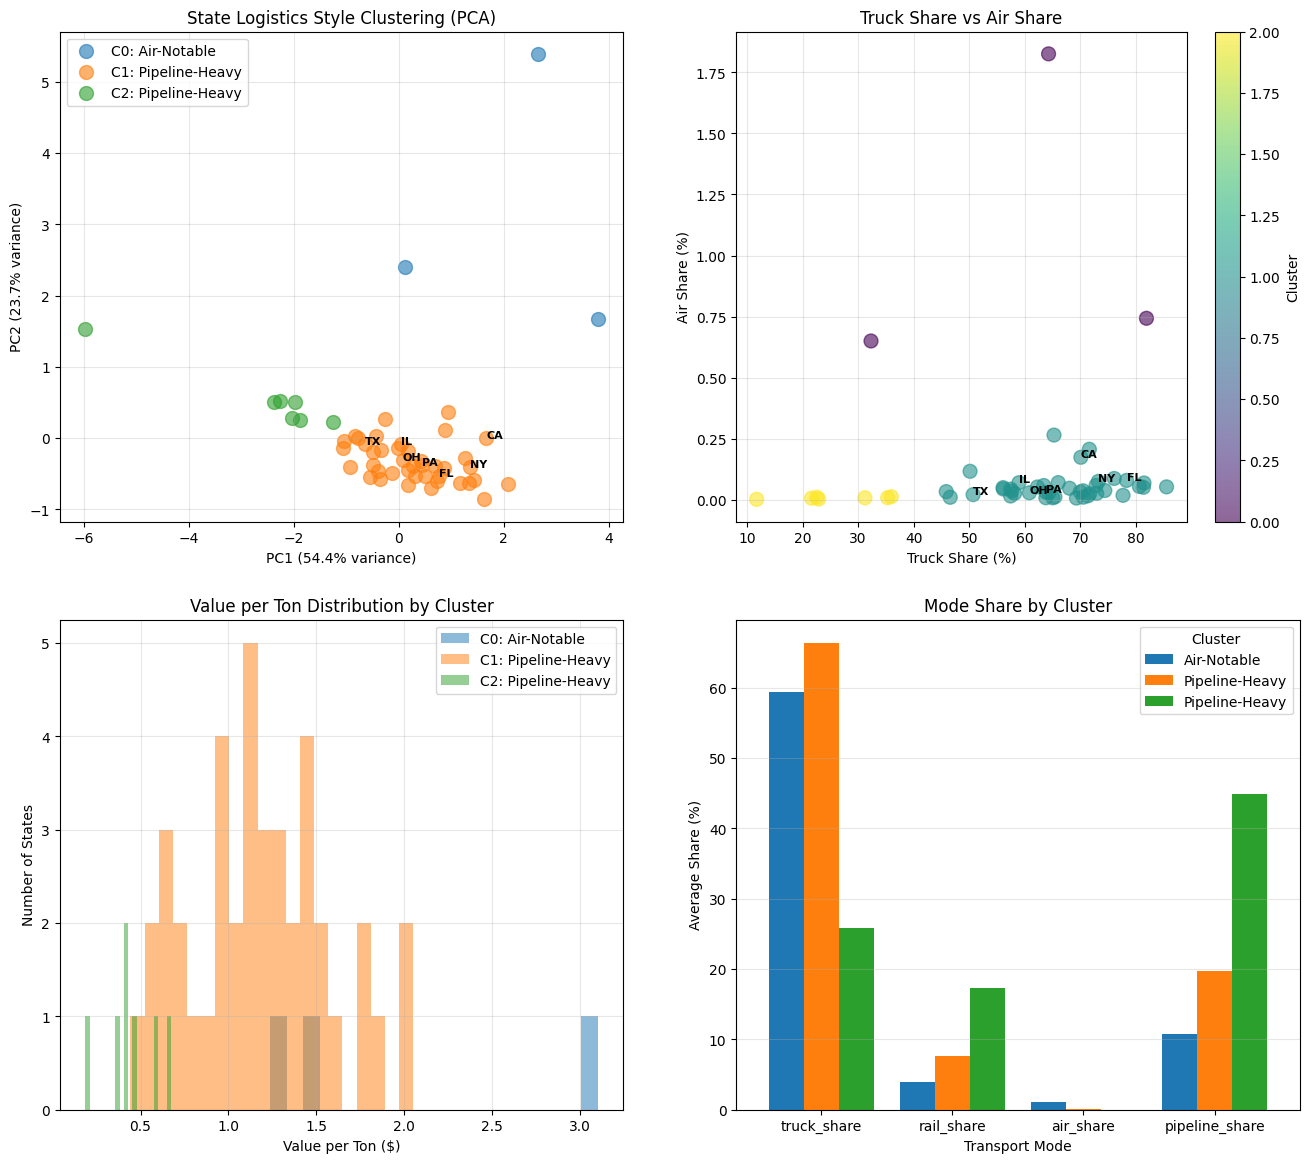

In [4]:
# ============================================================
# 주(State) 단위 물류 스타일 클러스터링
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("주(State) 단위 물류 스타일 클러스터링")
print("="*70)

# ============================================================
# 1. 주별 모드 점유율 및 Value per Ton 계산
# ============================================================

# POST 기간 (2022-2024) 평균
post_years = [2022, 2023, 2024]

# 각 주별로 집계 (origin + destination 합산)
state_profiles = []

# FIPS to State 매핑 (주요 주만)
FIPS_TO_STATE = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA',
    8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC', 12: 'FL',
    13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME',
    24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH',
    34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND',
    39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI',
    45: 'SC', 46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT',
    50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}

# 전체 주 리스트
all_states = sorted(FIPS_TO_STATE.keys())

for state_id in all_states:
    state_code = FIPS_TO_STATE.get(state_id, f"State_{state_id}")
    
    # 해당 주가 origin 또는 destination인 데이터
    state_data = df[
        (df['state_orig'] == state_id) | 
        (df['state_dest'] == state_id)
    ].copy()
    
    if len(state_data) == 0:
        continue
    
    # POST 기간 평균
    state_mode_tons = state_data.groupby('dms_mode').agg({
        'tons_2022': 'sum',
        'tons_2023': 'sum',
        'tons_2024': 'sum',
        'value_2022': 'sum',
        'value_2023': 'sum',
        'value_2024': 'sum'
    }).reset_index()
    
    state_mode_tons['avg_tons'] = (state_mode_tons['tons_2022'] + 
                                     state_mode_tons['tons_2023'] + 
                                     state_mode_tons['tons_2024']) / 3
    state_mode_tons['avg_value'] = (state_mode_tons['value_2022'] + 
                                      state_mode_tons['value_2023'] + 
                                      state_mode_tons['value_2024']) / 3
    
    # 총 물동량
    total_tons = state_mode_tons['avg_tons'].sum()
    total_value = state_mode_tons['avg_value'].sum()
    
    if total_tons == 0:
        continue
    
    # 모드별 점유율 계산
    truck_share = state_mode_tons[state_mode_tons['dms_mode'] == 1]['avg_tons'].sum() / total_tons * 100
    rail_share = state_mode_tons[state_mode_tons['dms_mode'] == 2]['avg_tons'].sum() / total_tons * 100
    water_share = state_mode_tons[state_mode_tons['dms_mode'] == 3]['avg_tons'].sum() / total_tons * 100
    air_share = state_mode_tons[state_mode_tons['dms_mode'] == 4]['avg_tons'].sum() / total_tons * 100
    multiple_share = state_mode_tons[state_mode_tons['dms_mode'] == 5]['avg_tons'].sum() / total_tons * 100
    pipeline_share = state_mode_tons[state_mode_tons['dms_mode'] == 6]['avg_tons'].sum() / total_tons * 100
    
    # Value per Ton
    avg_value_per_ton = total_value / total_tons if total_tons > 0 else 0
    
    state_profiles.append({
        'state_id': state_id,
        'state': state_code,
        'total_tons': total_tons,
        'total_value': total_value,
        'truck_share': truck_share,
        'rail_share': rail_share,
        'water_share': water_share,
        'air_share': air_share,
        'multiple_share': multiple_share,
        'pipeline_share': pipeline_share,
        'value_per_ton': avg_value_per_ton
    })

# DataFrame 생성
state_df = pd.DataFrame(state_profiles)

print(f"\n분석 대상 주: {len(state_df)}개")
print(f"\n상위 5개 주 (물동량 기준):")
print(state_df.nlargest(5, 'total_tons')[['state', 'total_tons', 'truck_share', 'air_share', 'value_per_ton']])

# ============================================================
# 2. 클러스터링 수행
# ============================================================

# 클러스터링 변수 선택
cluster_features = ['truck_share', 'rail_share', 'air_share', 'value_per_ton']
X = state_df[cluster_features].values

# 정규화 (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optimal K 찾기 (Elbow Method)
inertias = []
silhouette_scores = []
K_range = range(2, 10)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# 최적 K 선택 (Silhouette Score 최대)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n최적 클러스터 수: {optimal_k} (Silhouette Score: {max(silhouette_scores):.3f})")

# 최종 클러스터링
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
state_df['cluster'] = kmeans_final.fit_predict(X_scaled)

# ============================================================
# 3. 클러스터별 특성 분석
# ============================================================

print("\n" + "="*70)
print("클러스터별 특성")
print("="*70)

cluster_summary = state_df.groupby('cluster').agg({
    'truck_share': 'mean',
    'rail_share': 'mean',
    'water_share': 'mean',
    'air_share': 'mean',
    'pipeline_share': 'mean',
    'value_per_ton': 'mean',
    'total_tons': 'sum',
    'state': 'count'
}).rename(columns={'state': 'num_states'})

# 클러스터 명명
def name_cluster(row):
    """클러스터 특성 기반 이름 부여"""
    if row['truck_share'] > 70:
        return 'Truck-Dominant'
    elif row['pipeline_share'] > 15:
        return 'Pipeline-Heavy'
    elif row['rail_share'] > 10:
        return 'Rail-Significant'
    elif row['air_share'] > 0.05:
        return 'Air-Notable'
    elif row['value_per_ton'] > 2.0:
        return 'High-Value'
    else:
        return 'Balanced'

cluster_summary['cluster_name'] = cluster_summary.apply(name_cluster, axis=1)

print("\n클러스터 요약:")
print(cluster_summary[['cluster_name', 'num_states', 'truck_share', 'rail_share', 'air_share', 'pipeline_share', 'value_per_ton']].to_string())

# 각 클러스터별 주 리스트
print("\n" + "="*70)
print("클러스터별 주 목록")
print("="*70)

for cluster_id in sorted(state_df['cluster'].unique()):
    cluster_name = cluster_summary.loc[cluster_id, 'cluster_name']
    cluster_states = state_df[state_df['cluster'] == cluster_id].sort_values('total_tons', ascending=False)
    
    print(f"\n[Cluster {cluster_id}: {cluster_name}] ({len(cluster_states)}개 주)")
    print(f"평균 특성:")
    print(f"  Truck: {cluster_summary.loc[cluster_id, 'truck_share']:.1f}%")
    print(f"  Rail:  {cluster_summary.loc[cluster_id, 'rail_share']:.1f}%")
    print(f"  Air:   {cluster_summary.loc[cluster_id, 'air_share']:.3f}%")
    print(f"  Pipeline: {cluster_summary.loc[cluster_id, 'pipeline_share']:.1f}%")
    print(f"  Value/Ton: ${cluster_summary.loc[cluster_id, 'value_per_ton']:.2f}")
    
    print(f"\n주 목록:")
    for _, state in cluster_states.iterrows():
        print(f"  {state['state']:3s}: Truck {state['truck_share']:5.1f}%, "
              f"Rail {state['rail_share']:5.1f}%, "
              f"Air {state['air_share']:6.3f}%, "
              f"Value/Ton ${state['value_per_ton']:5.2f}")

# ============================================================
# 4. 시각화
# ============================================================

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
state_df['pca1'] = X_pca[:, 0]
state_df['pca2'] = X_pca[:, 1]

# Plot 1: PCA Scatter
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Subplot 1: PCA Clustering
ax1 = axes[0, 0]
for cluster_id in sorted(state_df['cluster'].unique()):
    cluster_data = state_df[state_df['cluster'] == cluster_id]
    cluster_name = cluster_summary.loc[cluster_id, 'cluster_name']
    ax1.scatter(cluster_data['pca1'], cluster_data['pca2'], 
                label=f'C{cluster_id}: {cluster_name}', s=100, alpha=0.6)

# 주요 주 라벨링
major_states = ['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH']
for _, row in state_df.iterrows():
    if row['state'] in major_states:
        ax1.annotate(row['state'], (row['pca1'], row['pca2']), 
                     fontsize=8, fontweight='bold')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('State Logistics Style Clustering (PCA)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Truck vs Air
ax2 = axes[0, 1]
scatter = ax2.scatter(state_df['truck_share'], state_df['air_share'], 
                      c=state_df['cluster'], cmap='viridis', s=100, alpha=0.6)
for _, row in state_df.iterrows():
    if row['state'] in major_states:
        ax2.annotate(row['state'], (row['truck_share'], row['air_share']), 
                     fontsize=8, fontweight='bold')
ax2.set_xlabel('Truck Share (%)')
ax2.set_ylabel('Air Share (%)')
ax2.set_title('Truck Share vs Air Share')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Cluster')

# Subplot 3: Value per Ton distribution
ax3 = axes[1, 0]
for cluster_id in sorted(state_df['cluster'].unique()):
    cluster_data = state_df[state_df['cluster'] == cluster_id]
    cluster_name = cluster_summary.loc[cluster_id, 'cluster_name']
    ax3.hist(cluster_data['value_per_ton'], bins=20, alpha=0.5, 
             label=f'C{cluster_id}: {cluster_name}')
ax3.set_xlabel('Value per Ton ($)')
ax3.set_ylabel('Number of States')
ax3.set_title('Value per Ton Distribution by Cluster')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Subplot 4: Mode Share by Cluster
ax4 = axes[1, 1]
cluster_modes = cluster_summary[['truck_share', 'rail_share', 'air_share', 'pipeline_share']].T
cluster_modes.columns = [cluster_summary.loc[i, 'cluster_name'] for i in cluster_modes.columns]
cluster_modes.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_xlabel('Transport Mode')
ax4.set_ylabel('Average Share (%)')
ax4.set_title('Mode Share by Cluster')
ax4.legend(title='Cluster')
ax4.grid(True, alpha=0.3, axis='y')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=0)


# ============================================================
# 5. 클러스터별 대표 주 식별
# ============================================================

print("\n" + "="*70)
print("클러스터별 대표 주 (Representative States)")
print("="*70)

for cluster_id in sorted(state_df['cluster'].unique()):
    cluster_name = cluster_summary.loc[cluster_id, 'cluster_name']
    cluster_states = state_df[state_df['cluster'] == cluster_id]
    
    # 클러스터 중심에 가장 가까운 주 찾기
    cluster_center = kmeans_final.cluster_centers_[cluster_id]
    cluster_states_scaled = scaler.transform(cluster_states[cluster_features].values)
    
    distances = np.linalg.norm(cluster_states_scaled - cluster_center, axis=1)
    representative_idx = np.argmin(distances)
    representative = cluster_states.iloc[representative_idx]
    
    print(f"\n[Cluster {cluster_id}: {cluster_name}]")
    print(f"대표 주: {representative['state']}")
    print(f"  총 물동량: {representative['total_tons']:,.0f} tons")
    print(f"  Truck: {representative['truck_share']:.1f}%")
    print(f"  Rail: {representative['rail_share']:.1f}%")
    print(f"  Air: {representative['air_share']:.3f}%")
    print(f"  Pipeline: {representative['pipeline_share']:.1f}%")
    print(f"  Value/Ton: ${representative['value_per_ton']:.2f}")

print("\n" + "="*70)
print("분석 완료!")
print("="*70)